# Lagrange Interpolation

## Problem
Given n points (x₀, y₀), (x₁, y₁), ..., (xₙ, yₙ),
we want to find a polynomial P(x) of degree n-1 that passes exactly through all these points.

## Formula

P(x) = Σ yᵢ · Lᵢ(x)

where the Lagrange basis polynomials are defined by :

Lᵢ(x) = Π (x - xⱼ) / (xᵢ - xⱼ)   for j ≠ i

## Key property

- Lᵢ(xᵢ) = 1  → equals 1 at its own point
- Lᵢ(xⱼ) = 0  → equals 0 at all other points

This guarantees that P(xᵢ) = yᵢ for each point.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def L(i, x_points, x):
    result = 1
    for j in range(len(x_points)):
        if j != i:
            result *= (x - x_points[j]) / (x_points[i] - x_points[j])
    return result

In [6]:
x_points = [0, 1, 2]

# L₀(0) doit valoir 1, L₀(1) et L₀(2) doivent valoir 0
print(L(0, x_points, 0))  # attendu : 1
print(L(0, x_points, 1))  # attendu : 0
print(L(0, x_points, 2))  # attendu : 0

1.0
-0.0
0.0


In [8]:
def lagrange(x_points, y_points, x):
    result = 0
    for i in range(len(x_points)):
        result += y_points[i]*L(i, x_points, x)
    return result

In [10]:
x_points = [0, 1, 2]
y_points = [1, 3, 2]

# Vérification : le polynôme doit passer par les points
print(lagrange(x_points, y_points, 0))
print(lagrange(x_points, y_points, 1))
print(lagrange(x_points, y_points, 2))

# Estimation entre deux points
print(lagrange(x_points, y_points, 1.5))  # valeur interpolée

1.0
3.0
2.0
2.875


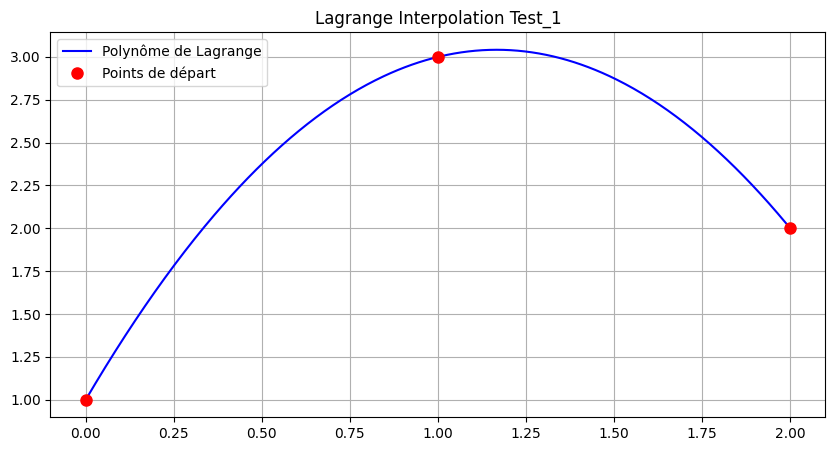

In [15]:
x_points = [0, 1, 2]
y_points = [1, 3, 2]

x = np.linspace(0, 2, 500)
y = [lagrange(x_points, y_points, xi) for xi in x]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'b-', label='Polynôme de Lagrange')
ax.plot(x_points, y_points, 'ro', markersize=8, label='Points de départ')
ax.set_title('Lagrange Interpolation Test_1')
ax.legend()
ax.grid(True)
plt.show()

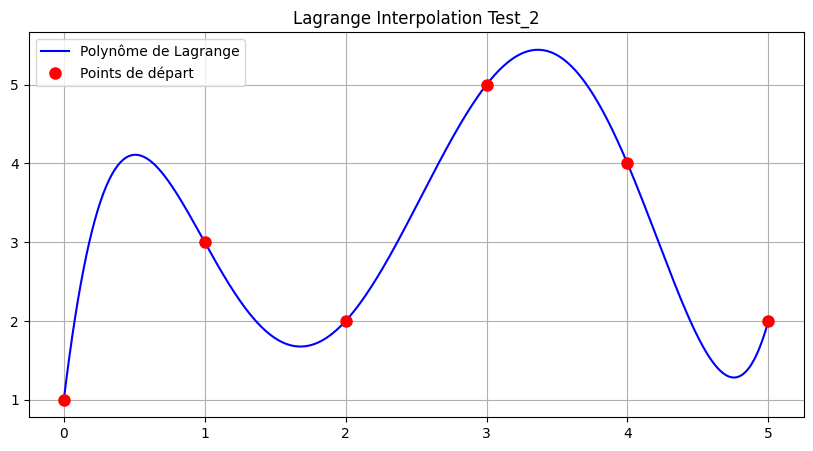

In [16]:
x_points = [0, 1, 2, 3, 4, 5]
y_points = [1, 3, 2, 5, 4, 2]

x = np.linspace(0, 5, 500)
y = [lagrange(x_points, y_points, xi) for xi in x]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'b-', label='Polynôme de Lagrange')
ax.plot(x_points, y_points, 'ro', markersize=8, label='Points de départ')
ax.set_title('Lagrange Interpolation Test_2')
ax.legend()
ax.grid(True)
plt.show()

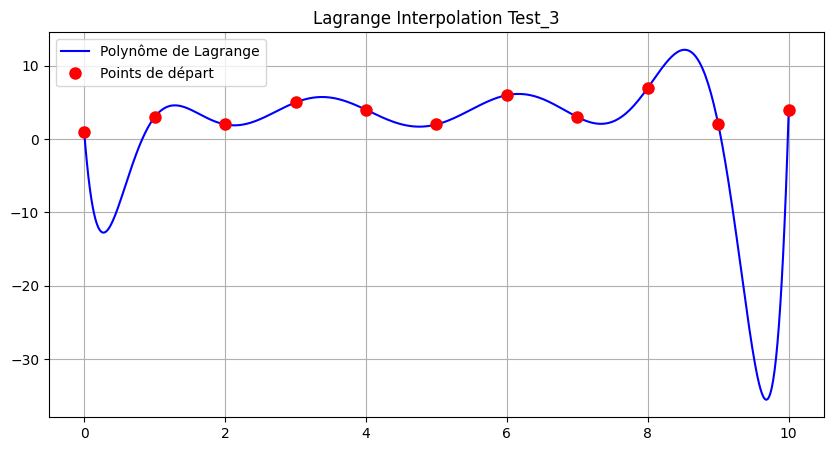

In [19]:
x_points = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y_points = [1, 3, 2, 5, 4, 2, 6, 3, 7, 2, 4]

x = np.linspace(0, 10, 500)
y = [lagrange(x_points, y_points, xi) for xi in x]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'b-', label='Polynôme de Lagrange')
ax.plot(x_points, y_points, 'ro', markersize=8, label='Points de départ')
ax.set_title('Lagrange Interpolation Test_3')
ax.legend()
ax.grid(True)
plt.show()

## Cubic Spline Interpolation

### Problem with Lagrange
With many points, the Lagrange polynomial oscillates wildly at the edges
(Runge's phenomenon). We need a better approach.

### Idea
Instead of one big polynomial, use a different cubic polynomial
between each pair of consecutive points :

- Sᵢ(x) = aᵢ + bᵢ(x - xᵢ) + cᵢ(x - xᵢ)² + dᵢ(x - xᵢ)³

### Smoothness conditions
At each interior point, we impose :
- Continuity : Sᵢ(xᵢ₊₁) = Sᵢ₊₁(xᵢ₊₁)
- First derivative continuity : Sᵢ'(xᵢ₊₁) = Sᵢ₊₁'(xᵢ₊₁)
- Second derivative continuity : Sᵢ''(xᵢ₊₁) = Sᵢ₊₁''(xᵢ₊₁)

### Advantage over Lagrange
Local polynomials → no wild oscillations at the edges.

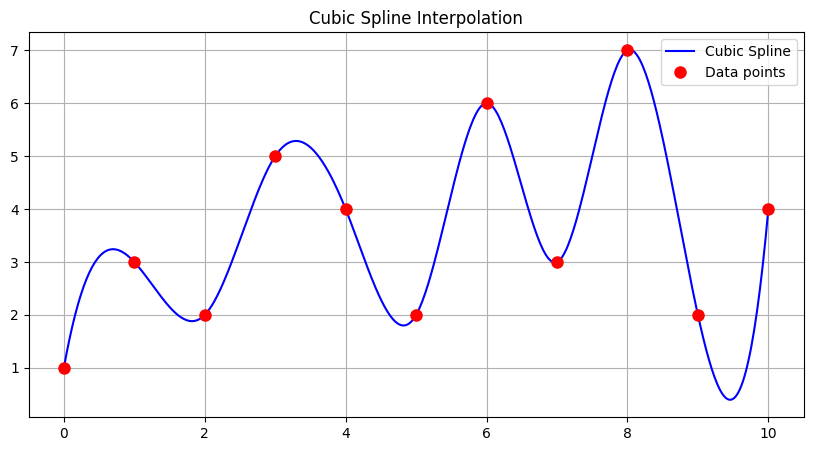

In [21]:
from scipy.interpolate import CubicSpline

x_points = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_points = np.array([1, 3, 2, 5, 4, 2, 6, 3, 7, 2, 4])

cs = CubicSpline(x_points, y_points)

x = np.linspace(0, 10, 500)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, cs(x), 'b-', label='Cubic Spline')
ax.plot(x_points, y_points, 'ro', markersize=8, label='Data points')
ax.set_title('Cubic Spline Interpolation')
ax.legend()
ax.grid(True)
plt.show()

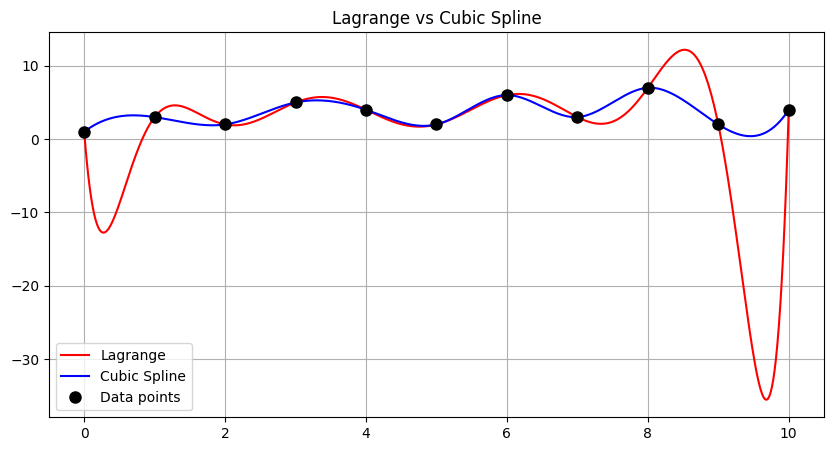

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

# Lagrange
y_lagrange = [lagrange(list(x_points), list(y_points), xi) for xi in x]
ax.plot(x, y_lagrange, 'r-', label='Lagrange')

# Spline
ax.plot(x, cs(x), 'b-', label='Cubic Spline')

# Points
ax.plot(x_points, y_points, 'ko', markersize=8, label='Data points')

ax.set_title('Lagrange vs Cubic Spline')
ax.legend()
ax.grid(True)
plt.show()